# Multi-phosphorylation switches

This notebook loads **`output/analyze/multiphos_switches.tsv`** (from `analyze/multiphos_switches.py`) and **`data.tsv`** for follow-up.

**What a row means:** same `geneid` in one `condition` has at least two sites; the strongest positive and strongest negative *signed scores* (Log2FC × −log10 p) both exceed the script cutoffs. `score_span` measures how separated those poles are.

Run the analysis pipeline first (e.g. `python analyze/multiphos_switches.py` or `python run_all.py`). Kernel working directory can be repo root or `notebooks/` — the next cell detects the project root automatically.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- project root (repo containing data.tsv) ---
def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Could not find project root (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402

SW_PATH = ROOT / "output" / "analyze" / "multiphos_switches.tsv"
DATA_PATH = ROOT / "data.tsv"

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ROOT =", ROOT)

ROOT = /Users/ph/Documents/phospho_mhg_anno


## Load switches table

In [2]:
if not SW_PATH.is_file():
    raise FileNotFoundError(f"Run multiphos_switches first. Missing: {SW_PATH}")

sw = pd.read_csv(SW_PATH, sep="\t")
display(sw.head(12))
print(sw.shape)
# Avoid describe(include="all"): pandas leaves NaN where a stat does not apply to that dtype
# (no mean for gene names; no quartiles for condition labels).
print("Numeric columns:")
display(sw.describe().T)
print("condition / geneid / sites (counts, uniques, top):")
display(sw[["condition", "geneid", "best_pos_site", "best_neg_site"]].astype(str).describe().T)

,condition,geneid,n_sites,best_pos_site,best_pos_score,best_pos_log2fc,best_neg_site,best_neg_score,best_neg_log2fc,score_span
0,αCD3_10min,DPYSL2,3,DPYSL2-S517,36.403200,6.400,DPYSL2-T514,-51.432255,-7.099,87.835455
1,αCD3_10min,BCL11B,3,BCL11B-S169,34.333236,5.166,BCL11B-S772,-31.434312,-5.446,65.767548
2,αCD3_10min,RIF1,3,RIF1-S2348,50.095968,7.124,RIF1-S2157,-7.498358,-3.547,57.594326
3,αCD3_10min,BSG,3,BSG-S367,47.099384,7.582,BSG-T237,-3.060920,-2.360,50.160304
4,αCD3_10min,CLIP1,3,CLIP1-S348,46.337104,7.288,CLIP1-S195,-3.583280,-1.880,49.920384
5,αCD3_10min,SLC2A1,3,SLC2A1-S226,6.306368,3.736,SLC2A1-T238,-40.837092,-6.117,47.143460
6,αCD3_10min,SMARCD2,2,SMARCD2-T217,37.780330,5.365,SMARCD2-Y197,-7.700400,-4.464,45.480730
7,αCD3_10min,TBC1D10B,3,TBC1D10B-T150,27.309339,7.419,TBC1D10B-S687,-13.480940,-3.190,40.790279
8,αCD3_10min,EIF4G3,3,EIF4G3-S1156,29.004507,5.453,EIF4G3-S495,-9.132080,-4.328,38.136587
9,αCD3_10min,PRKAA1,2,PRKAA1-S397,31.865800,4.504,PRKAA1-T488,-5.857248,-4.656,37.723048


(594, 10)
Numeric columns:


,count,mean,std,min,25%,50%,75%,max
n_sites,594.0,3.867003,3.363953,2.000000,2.000000,3.000000,4.000000,27.000000
best_pos_score,594.0,13.756751,10.414577,2.016112,6.871907,11.055718,17.026867,84.039316
best_pos_log2fc,594.0,4.074274,1.561087,0.818000,2.890250,3.953000,5.204750,10.067000
best_neg_score,594.0,-9.312619,8.816695,-78.911030,-11.011400,-6.700013,-3.985752,-2.005200
best_neg_log2fc,594.0,-3.743626,1.568014,-12.238000,-4.696750,-3.548500,-2.618250,-0.938000
score_span,594.0,23.069370,13.481066,4.493891,13.634270,20.080760,29.149795,95.548141


condition / geneid / sites (counts, uniques, top):


,count,unique,top,freq
condition,594,8,αCD3_αCD2_5min,90
geneid,594,162,ARHGAP30,8
best_pos_site,594,235,BCL9L-S118,8
best_neg_site,594,208,NCOA2-S2,8


## Summary tables

- **Switches per condition**
- **Genes recurring across conditions** (same gene, multiple conditions = stronger candidate for shared “opposing phospho” biology)
- **`n_sites` distribution** (more sites → more confident the pattern is not just two noisy measurements)

In [3]:
counts = sw.groupby("condition").size().rename("n_switches").reset_index()
display(counts.sort_values("n_switches", ascending=False))

gene_n = sw.groupby("geneid")["condition"].nunique().rename("n_conditions").reset_index()
recurrent = gene_n[gene_n["n_conditions"] >= 2].sort_values("n_conditions", ascending=False)
print("Genes in ≥2 conditions:", len(recurrent))
display(recurrent.head(25))

display(sw["n_sites"].describe().to_frame("n_sites"))

,condition,n_switches
5,αCD3_αCD2_5min,90
4,αCD3_αCD2_10min,87
3,αCD3_αCD226_5min,80
6,αCD3_αICOS_10min,79
7,αCD3_αICOS_5min,67
0,αCD3_10min,66
1,αCD3_5min,64
2,αCD3_αCD226_10min,61


Genes in ≥2 conditions: 139


,geneid,n_conditions
17,BCL9L,8
9,ARHGAP30,8
84,MED1,8
92,NCOA2,8
122,RCSD1,8
...,...,...
46,EMD,6
102,PCNT,6
4,AKAP13,6
100,PBRM1,6


,n_sites
count,594.000000
mean,3.867003
std,3.363953
min,2.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,27.000000


## Figure: switches per condition

/Users/ph/.pyenv/versions/3.12.7/lib/python3.12/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


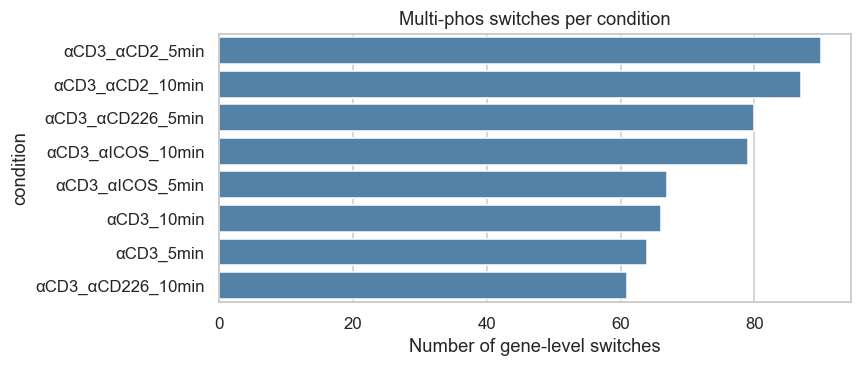

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
order = counts.sort_values("n_switches", ascending=False)["condition"]
sns.barplot(data=counts, y="condition", x="n_switches", order=order, ax=ax, color="steelblue")
ax.set_xlabel("Number of gene-level switches")
ax.set_title("Multi-phos switches per condition")
fig.tight_layout()
plt.show()

## Figure: top genes by `score_span` within each condition

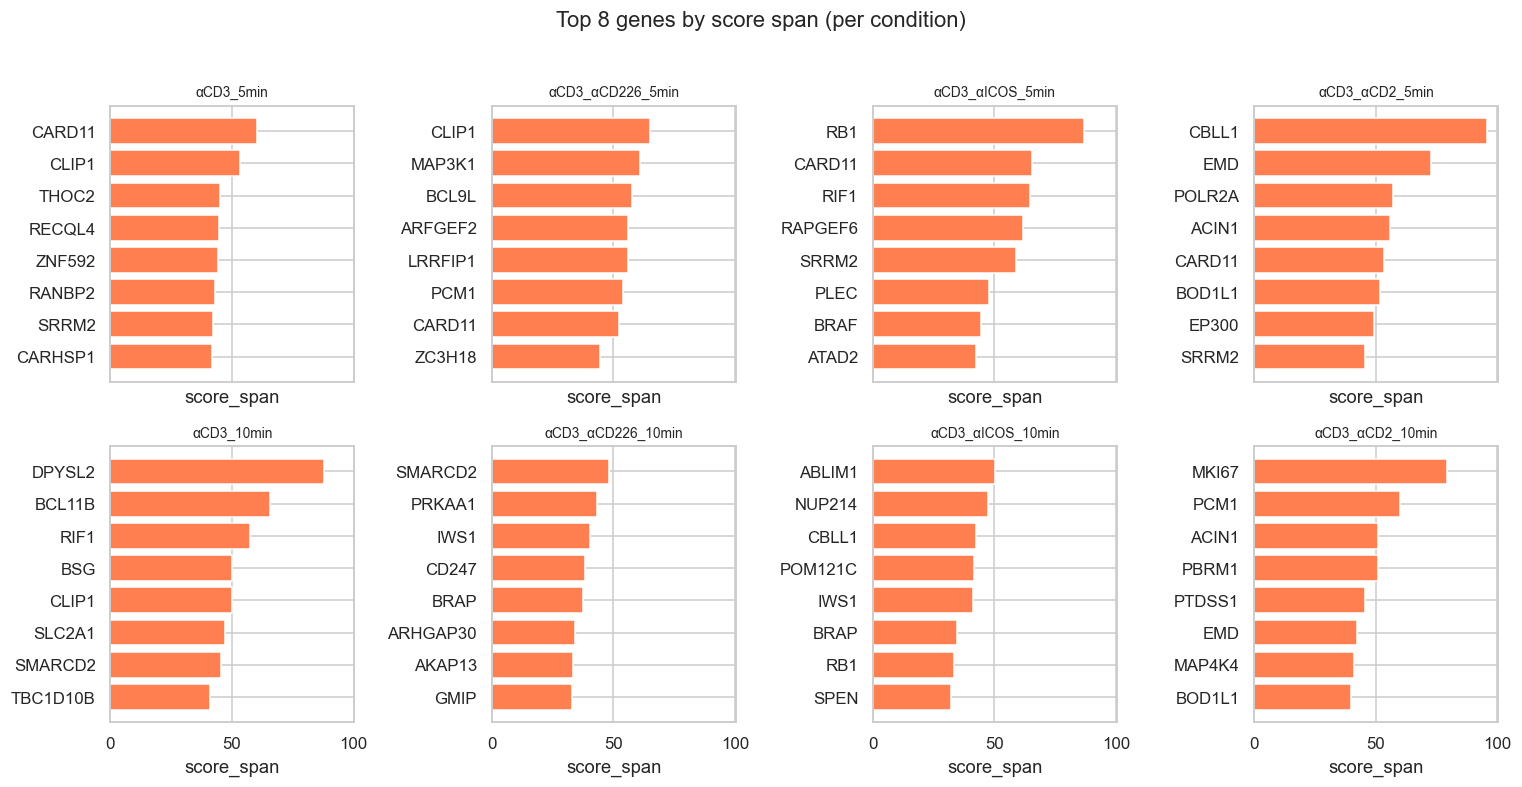

In [5]:
TOP = 8  # genes per panel

conds = [c.condition_id for c in CONDITIONS]
fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True)
axes = axes.ravel()
for ax, cid in zip(axes, conds):
    sub = sw[sw["condition"] == cid].nlargest(TOP, "score_span").sort_values("score_span")
    ax.barh(sub["geneid"], sub["score_span"], color="coral")
    ax.set_title(cid, fontsize=9)
    ax.set_xlabel("score_span")
fig.suptitle(f"Top {TOP} genes by score span (per condition)", y=1.02)
fig.tight_layout()
plt.show()

## Figure: recurrent genes × conditions (`score_span`)

Only genes that appear in **≥ `MIN_COND`** conditions. Cell value = **max** `score_span` across rows for that gene–condition pair (if duplicated).

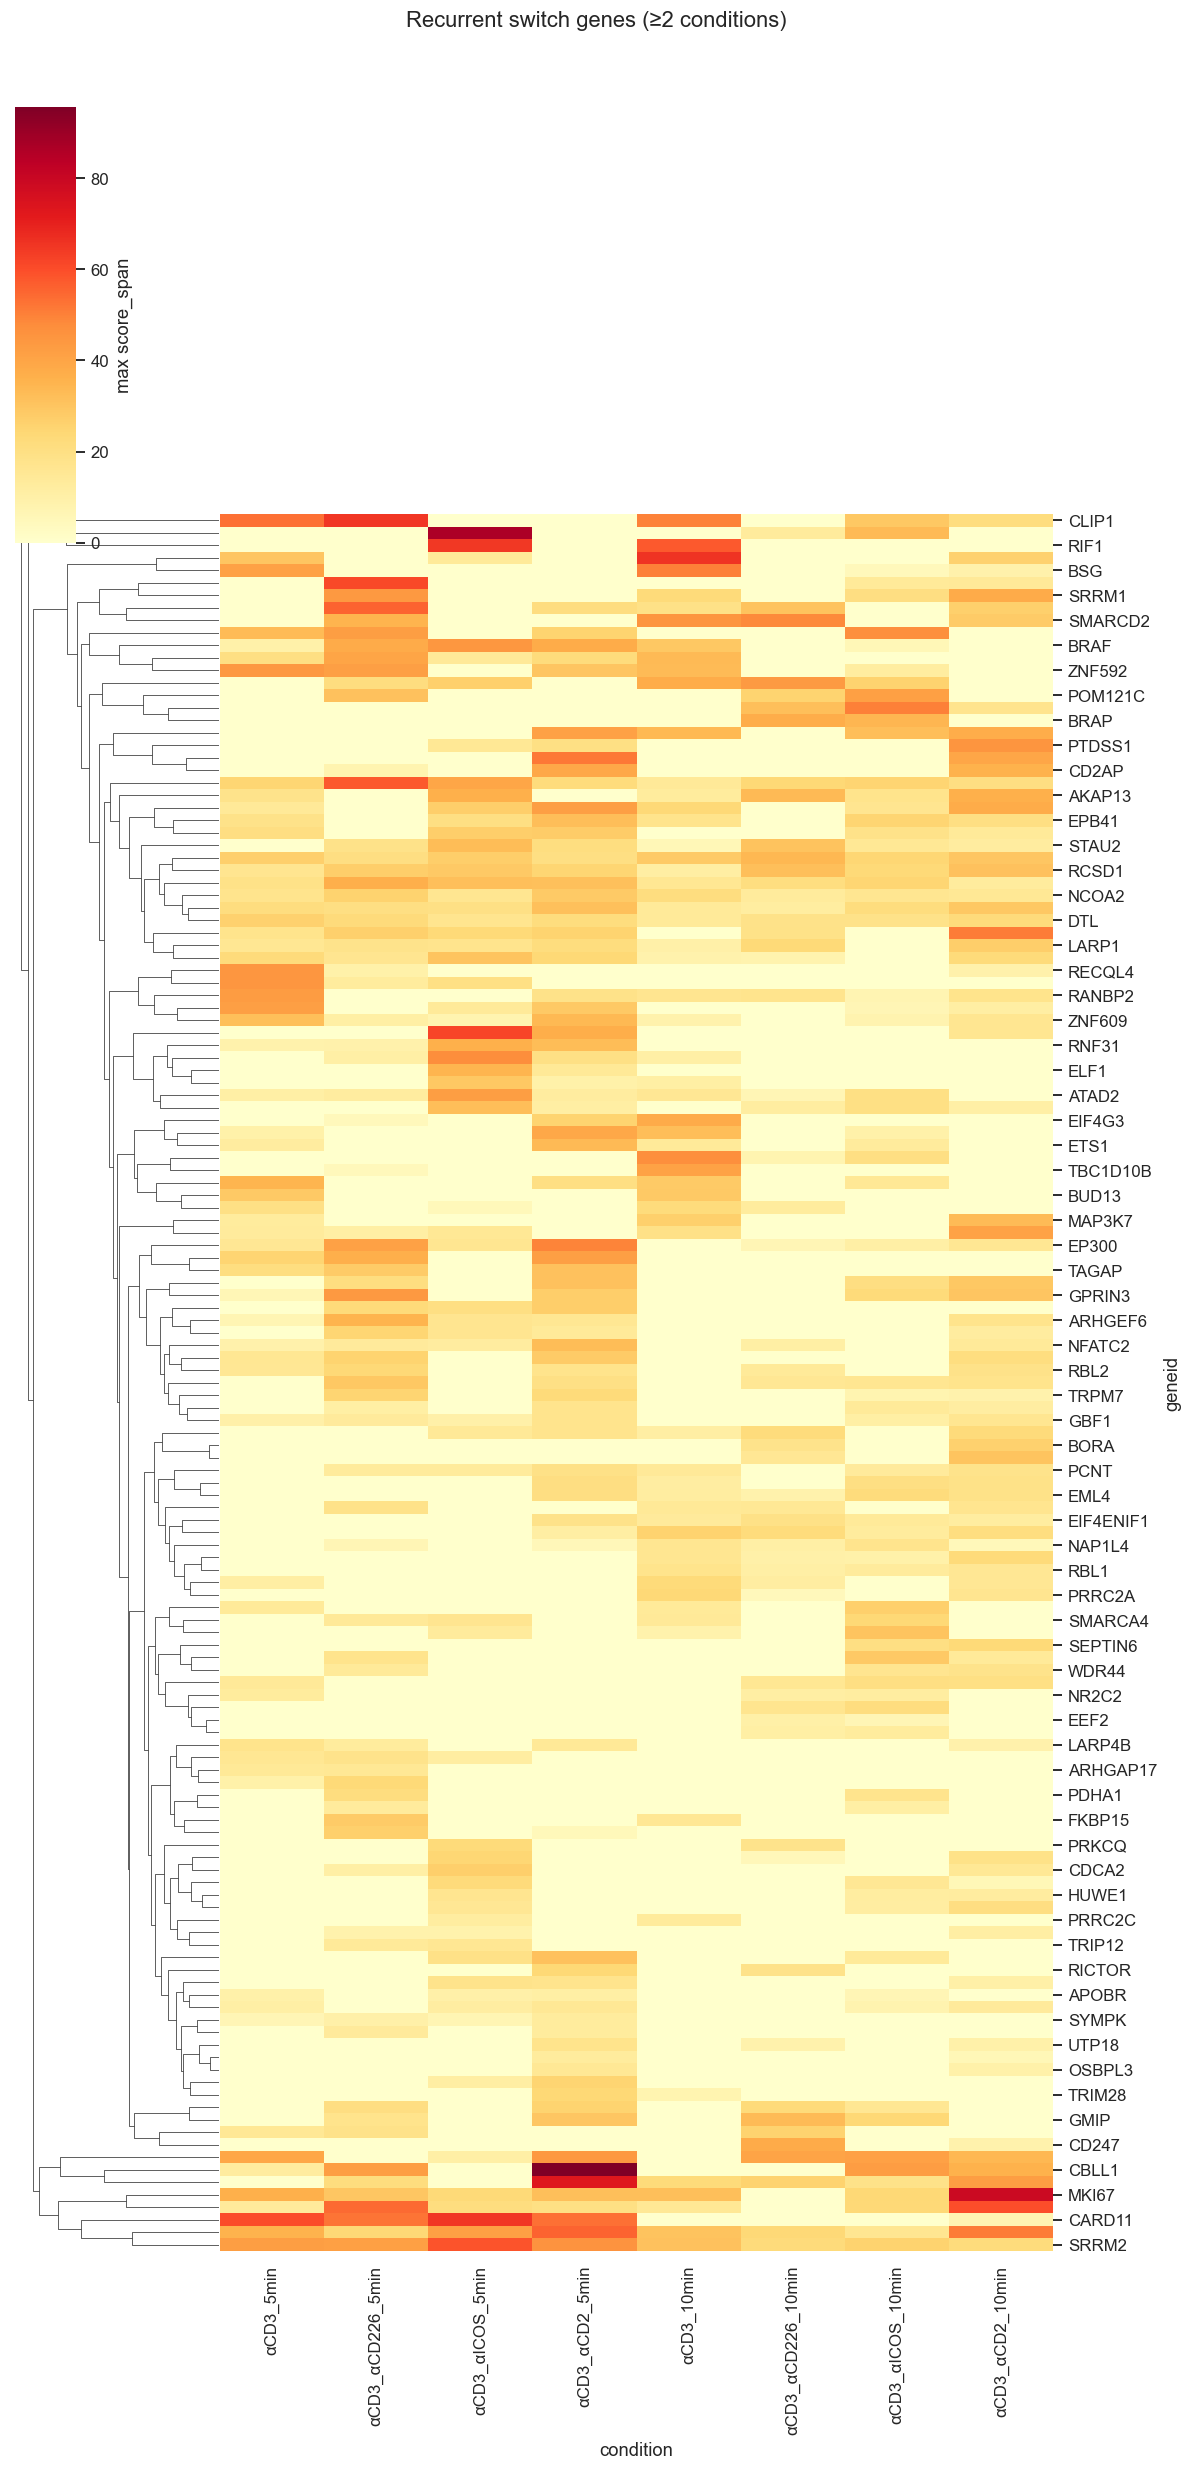

Matrix shape: (139, 8)


In [15]:
MIN_COND = 2
conds = [c.condition_id for c in CONDITIONS]
keep_genes = set(recurrent.loc[recurrent["n_conditions"] >= MIN_COND, "geneid"])
sub = sw[sw["geneid"].isin(keep_genes)].copy()
wide = sub.pivot_table(index="geneid", columns="condition", values="score_span", aggfunc="max")
# stable column order
cols = [c for c in conds if c in wide.columns]
wide = wide[cols].dropna(how="all")

h = min(22.0, 0.22 * len(wide) + 2.5)
g = sns.clustermap(wide.fillna(0), figsize=(11, h), cmap="YlOrRd", row_cluster=True, col_cluster=False,
                   cbar_kws={"label": "max score_span"})
g.fig.suptitle(f"Recurrent switch genes (≥{MIN_COND} conditions)", y=1.02)
plt.show()
print("Matrix shape:", wide.shape)

## Figure: positive vs negative pole strength

Text labels: **union** of the **top 19** rows by `best_pos_score` and the **top 19** by `best_neg_score` (most negative). Change `N_LABEL` in the next cell to adjust.

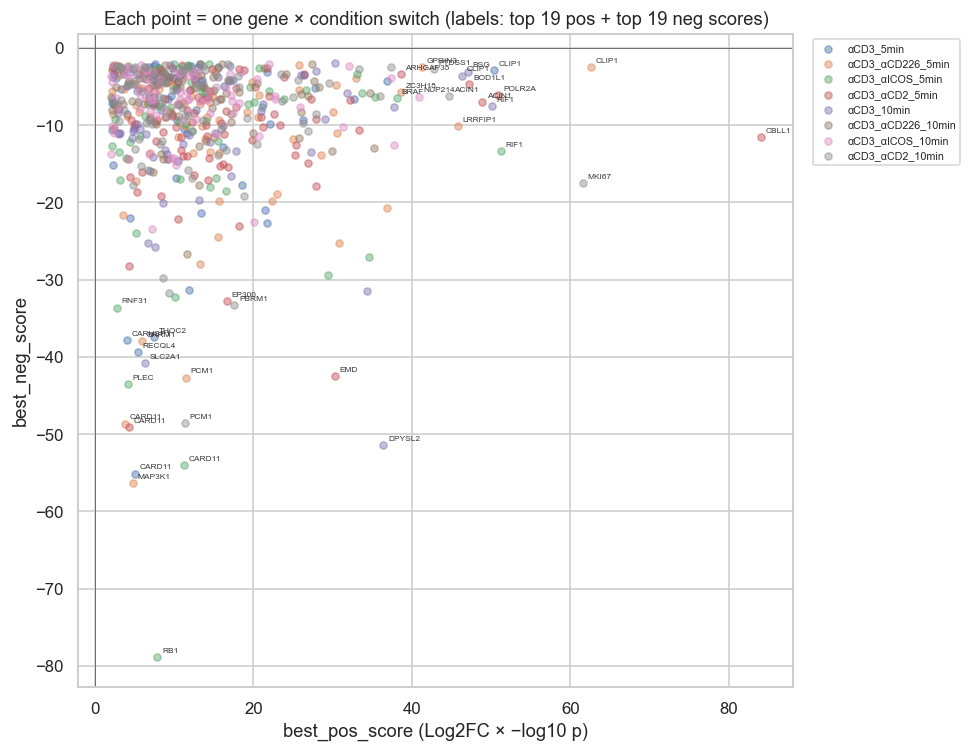

In [7]:
N_LABEL = 19  # label union of top N by positive pole and top N by negative pole
conds = [c.condition_id for c in CONDITIONS]
fig, ax = plt.subplots(figsize=(9, 7))
for cid in conds:
    s = sw[sw["condition"] == cid]
    ax.scatter(s["best_pos_score"], s["best_neg_score"], s=22, alpha=0.45, label=cid, rasterized=True)
ax.axhline(0, color="0.4", lw=0.6)
ax.axvline(0, color="0.4", lw=0.6)

sw_lab = sw.reset_index(drop=True)
top_pos = sw_lab.nlargest(N_LABEL, "best_pos_score")
top_neg = sw_lab.nsmallest(N_LABEL, "best_neg_score")
label_ix = set(top_pos.index) | set(top_neg.index)
lab = sw_lab.loc[sorted(label_ix)].drop_duplicates(
    subset=["condition", "geneid", "best_pos_score", "best_neg_score"]
)
for _, row in lab.iterrows():
    txt = str(row["geneid"])[:14]
    if len(str(row["geneid"])) > 14:
        txt += "…"
    ax.annotate(
        txt,
        (row["best_pos_score"], row["best_neg_score"]),
        fontsize=5.5,
        color="0.15",
        alpha=0.9,
        xytext=(3, 3),
        textcoords="offset points",
        clip_on=True,
    )

ax.set_xlabel("best_pos_score (Log2FC × −log10 p)")
ax.set_ylabel("best_neg_score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax.set_title(
    f"Each point = one gene × condition switch (labels: top {N_LABEL} pos + top {N_LABEL} neg scores)"
)
fig.tight_layout()
plt.show()

### 6. Paired lollipop (pos vs neg poles)